# DEG

## Data import DEG celltype

In [ ]:
dir_notebook = 'D:/Jupyter_notebook/Xenium_jupyter_notebook'

control = "WT"
test = "APP"

df_all = pd.read_excel(f'{dir_notebook}/analysis/{name_dir}/foldchanges/celltype/DEG_celltype_no-filter.xlsx', sheet_name=None)
df_expressed = {}
for key in df_all.keys():
    if control in df_all[key]["group"].unique():
        df_all[key] = df_all[key][df_all[key]['group'] == test]
    df_expressed[key] = df_all[key][
            (df_all[key]['pct_nz_group']>0.05) &
          (df_all[key]['mean_count']>= 0.01)
          ]
    df_all[key].index = df_all[key]['names']

In [ ]:
# df_filter = pd.read_excel('../notebook/analysis/circa-SD/DEG_celltype_filter.xlsx', sheet_name=None)

# for key in df_filter.keys():
#     df_filter[key] = df_filter[key][df_filter[key]['group'] == 'SD1']
#     df_filter[key].index = df_filter[key]['names']

In [ ]:
### Alternative filtering
df_filter = {}
for key in df_all.keys():
    df_filter[key] = df_all[key][(df_all[key]['pvals_adj'] < 0.05)
                                 & (df_all[key]['pct_nz_group'] > 0.05)
                                 & (df_all[key]['pct_nz_reference'] > 0.05)
                                 & (abs(df_all[key]['logfoldchanges']) > 0.26)
                                 & (df_all[key]['mean_count'] >=0.05)
                                 ]
# df_filter['SCH'].sort_values(by='logfoldchanges')

### All DEG

In [ ]:
list_of_DEG = []
for key in df_filter:
    list_temp = list(df_filter[key]['names'])
    list_of_DEG.extend(list_temp)

In [ ]:
unique_gene = set(list_of_DEG)
count_dict = {}
for gene in unique_gene:
    count_dict[gene] = list_of_DEG.count(gene)

In [ ]:
df = pd.DataFrame(data ={"Gene": list(unique_gene)})

In [ ]:
df['count'] = df['Gene'].map(count_dict)
df.sort_values(by='count', inplace = True, ascending = False)
df.shape

In [ ]:
df.sort_values(by='count')

In [ ]:
mean_exp = pd.DataFrame(columns=['Gene','mean_count'])
a = 0
for key in df_filter.keys():
    for gene in df_filter[key]['names']:
        temp_count = df_filter[key]['mean_count'][gene]
        mean_exp.loc[a] = [gene, temp_count]
        a +=1

In [ ]:
mean_exp = mean_exp.groupby('Gene')['mean_count'].mean()
mean_exp.head()

In [ ]:
dict_mean_exp = dict(zip(mean_exp.index,mean_exp.values))

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2, figsize=(8,3))
ax = ax.flatten()
ax[1].barh(y=df['Gene'][0:20], height=0.8, width=df['count'][0:20], edgecolor = 'black')
# plt.hist(x=df['count'])
sns.histplot(df['count'], element="bars", cumulative= False, fill= True, common_norm=False,kde = True,
             stat='frequency', ax=ax[0])
plt.xlabel('Number of celltypes')
# plt.yscale("log")

In [ ]:
from module.misc import cell_class
dict_cellclass = cell_class()

list_of_celltype = [key for key in df_filter.keys()]
df_celltype = pd.DataFrame(data = {'Celltype' : list_of_celltype})
df_celltype['Cellclass'] = df_celltype['Celltype'].apply(lambda x: dict_cellclass[x] if x in dict_cellclass.keys() else "Neuron")
df_celltype.sample(5)

In [ ]:
from module.misc import genes_list

gene_index = genes_list('brain_panel')

matrix = pd.DataFrame(data = {'Neuron':np.zeros(len(gene_index)),
                              "Glial" : np.zeros(len(gene_index)),
                              'Vascular': np.zeros(len(gene_index)),
                              'Ependymal': np.zeros(len(gene_index))}, index = gene_index)

class_list = df_celltype.groupby('Cellclass')['Celltype'].unique()

for nb, class_ in enumerate(class_list):
    class_for_matrix = class_list.index[nb]
    for celltype_ in class_:
        list_temp = list(df_filter[celltype_]['names'])
        for gene in list_temp:
            matrix.loc[gene,class_for_matrix] += 1


matrix['total'] = matrix.sum(axis=1)
matrix.sort_values(by='total', ascending = False, inplace= True)

In [ ]:
y1 = matrix['Vascular'][0:25]
y2 = matrix['Ependymal'][0:25]
y3 = matrix['Glial'][0:25]
y4 = matrix['Neuron'][0:25]

import seaborn as sns
fig, ax = plt.subplots(1,2, figsize=(10,3))
ax = ax.flatten()

# plt.hist(x=df['count'])
sns.histplot(matrix['total'], element="bars", cumulative= False, fill= True, bins=50,
             common_norm=False, kde = True,
             stat='count', ax=ax[0])
ax[0].set_ylabel('Nb of genes')
ax[0].set_xlabel('Nb of celltype')

# ax[0].hist(x=matrix['total'])


ax[1].barh(y=matrix.index[0:25], height=0.8, width=y1, edgecolor = 'black', label = "Vascular")
ax[1].barh(y=matrix.index[0:25], height=0.8, width=y2, left = y1,  edgecolor = 'black', label = "Ependymal")
ax[1].barh(y=matrix.index[0:25], height=0.8, width=y3, left = y1+y2,  edgecolor = 'black',label = "Glial")
ax[1].barh(y=matrix.index[0:25], height=0.8, width=y4, left = y1+y2+y3,  edgecolor = 'black', label = "Neuron")
ax[1].legend()
ax[1].set_xlabel('Number of celltypes')

# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y1b, edgecolor = 'black', label = "Vascular")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y2b, left = y1b,  edgecolor = 'black', label = "Ependymal")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y3b, left = y1b+y2b,  edgecolor = 'black',label = "Glial")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y4b, left = y1b+y2b+y3b,  edgecolor = 'black', label = "Neuron")
# ax[2].legend()
# ax[2].set_xlabel('Number of celltypes')

plt.savefig(f'Gallery/{today}/DEG_distribution.svg', dpi = 300)



In [ ]:
matrix_bis = matrix[matrix['total']!=0]
matrix_bis['mean_count'] = matrix_bis.index.map(dict_mean_exp)
matrix_bis.head()

In [ ]:
y1 = matrix_bis['Vascular'][0:25]
y2 = matrix_bis['Ependymal'][0:25]
y3 = matrix_bis['Glial'][0:25]
y4 = matrix_bis['Neuron'][0:25]

y1b = matrix_bis['Vascular'][-25:-1]
y2b = matrix_bis['Ependymal'][-25:-1]
y3b = matrix_bis['Glial'][-25:-1]
y4b = matrix_bis['Neuron'][-25:-1]

import seaborn as sns
fig, ax = plt.subplots(2,1, figsize=(3,10))
ax = ax.flatten()

# plt.hist(x=df['count'])
sns.histplot(matrix_bis['total'], element="bars", cumulative= False, fill= True, bins=50,
             common_norm=False, kde = True,
             stat='count', ax=ax[0])

# ax[0].hist(x=matrix['total'])


ax[1].barh(y=matrix_bis.index[0:25], height=0.8, width=y1, edgecolor = 'black', label = "Vascular")
ax[1].barh(y=matrix_bis.index[0:25], height=0.8, width=y2, left = y1,  edgecolor = 'black', label = "Ependymal")
ax[1].barh(y=matrix_bis.index[0:25], height=0.8, width=y3, left = y1+y2,  edgecolor = 'black',label = "Glial")
ax[1].barh(y=matrix_bis.index[0:25], height=0.8, width=y4, left = y1+y2+y3,  edgecolor = 'black', label = "Neuron")
ax[1].legend()
ax[1].set_xlabel('Number of celltypes')

# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y1b, edgecolor = 'black', label = "Vascular")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y2b, left = y1b,  edgecolor = 'black', label = "Ependymal")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y3b, left = y1b+y2b,  edgecolor = 'black',label = "Glial")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y4b, left = y1b+y2b+y3b,  edgecolor = 'black', label = "Neuron")
# ax[2].legend()
# ax[2].set_xlabel('Number of celltypes')

plt.savefig(f'Gallery/{today}/DEG_distribution.svg', dpi = 300)



In [ ]:
# plt.scatter(x= matrix_bis['mean_count'], y = matrix_bis['total'])
plt.hist(matrix_bis['mean_count'])

## Quantif

In [ ]:
df_deg_quant = []
expressed = [len(df_expressed[key]) for key in df_expressed.keys()]
deg_quant = [len(df_filter[key]) for key in df_filter.keys()]
deg_up = [len(df_filter[key][df_filter[key]['logfoldchanges'] > 0]) for key in df_filter.keys()]
deg_down = [len(df_filter[key][df_filter[key]['logfoldchanges'] < 0]) for key in df_filter.keys()]

df_deg_quant = pd.DataFrame(data = {'Celltype' : df_filter.keys(),
                                    'Expressed' : expressed,
                                    'nb_DEG' : deg_quant,
                                    'Upregulated': deg_up,
                                    'Downregulated': deg_down})

df_deg_quant.index = df_deg_quant['Celltype']
df_deg_quant

In [ ]:
### Region only, remove liminal celltypes
# df_deg_quant.drop(['VLMC', "Ependymal","Choroid",'Tanycyte'], axis = 0, inplace=True)

### Celltypes only, remove tanycyte
df_deg_quant.drop(['Tanycyte'], axis = 0, inplace=True)

In [ ]:
# order_list = ['STR D2 Gaba', 'STR D1 Gaba', 'DG Glut', 'CA1 ProS Glut', 'CA2 FC IG Glut', 'CA3 Glut',
#                'LSX Gaba', 'CEA Gaba', 'STR PAL Gaba', 'COAa PAA MEA Glut', 'NLOT Glut', 'L2 3 IT PIR ENTl Glut',
#                  'CLA EPd CTX Glut', 'L6 CT CTX Glut', 'L6b CTX Glut', 'L5 NP CTX Glut', 'L5 ET CTX Glut',
#                    'L2 3 IT RSP Glut', 'L4 5 IT CTX Glut', 'L6 IT CTX Glut', 'Lamp5 Gaba', 'Vip Gaba', 'Sncg Gaba',
#                      'Sst Gaba', 'STR Gaba', 'Pvalb Gaba', 'RT ZI Gaba', 'AD Glut', 'PT Glut', 'RE Glut', 'CM Glut',
#                        'SMT Glut', 'VP Glut', 'LD Glut', 'VM MD Glut', 'AV Glut', 'MH Glut', 'TRS BAC Glut', 'BAC Glut',
#                          'MPO Glut', 'PAL STR Gaba Chol', 'PVT Glut', 'MEA Glut', 'BST Glut', 'SPA Glut', 'AHN Glut',
#                            'LHA Glut', 'LH Glut', 'PVH Glut', 'SCH Gaba', 'DG PIR Ex IMN', 'OB STR CTX IMN', 'Microglia',
#                              'Endothelial', 'SMC','Pericyte', 'Choroid', 'ABC', 'VLMC', 'Tanycyte', 'Ependymal',
#                                'Astro TE', 'OPC', 'Oligodendrocyte']
order_list = ['Oligodendrocyte', 'OPC', 'Astro NT', 'Astro TE', 'Ependymal', 'Pineal Glut', 'Tanycyte', 'CHOR', 'VLMC', 'Endothelial', 'Pericyte', 'Microglia', 'CA1 ProS Glut', 'CA2 FC IG Glut', 'CA3 Glut', 'DG Glut', 'L23 PIR ENTl Glut', 'MEA Glut', 'LA Glut', 'NLOT Glut', 'L23 CTX Glut', 'L23 RSP Glut', 'L4 CTX Glut', 'L6 CTX Glut', 'L5 CTX Glut', 'SUB ProS Glut', 'L6b CTX Glut', 'AD Glut', 'AV Glut', 'TH Glut', 'SN Dopa', 'LHA Glut', 'MB Glut', 'PAG Glut', 'HY Glut', 'LH Glut', 'VMH Glut', 'MM Glut', 'PVT Glut', 'PF Glut', 'APN Glut', 'SC Glut', 'MH Glut', 'BST Glut', 'LSX Gaba', 'SCH Gaba', 'Sst Gaba', 'MEA Gaba', 'BST Gaba', 'HY GABA', 'ARH GABA', 'Lamp5 Gaba', 'Vip Gaba', 'STR Gaba', 'STRv PAL Gaba', 'LGv Gaba', 'PRT Gaba', 'SC Gaba', 'ZI Gaba', 'SN Gaba', 'RT ZI GABA', 'Pvalb Gaba', 'STR D1D2 Gaba']


df_deg_quant["Celltype_order"] = pd.Categorical(df_deg_quant["Celltype"], categories=order_list, ordered = True)
df_deg_quant.sort_values('Celltype_order', inplace= True)
df_deg_quant.dropna(axis = 0, inplace= True)

In [ ]:
max(max(df_deg_quant['Upregulated']),max(df_deg_quant['Downregulated']))

In [ ]:
plt.figure(figsize=(3,10))
# df_deg_quant.sort_values(by='Downregulated', inplace=True)
# plt.barh(y = df_deg_quant["Celltype_order"].astype(str), width=df_deg_quant['Expressed'], height = 0.8, color =[], edgecolor = 'black', label = 'Expressed')
plt.barh(y = df_deg_quant["Celltype_order"].astype(str), width=df_deg_quant['Upregulated'], color = "#f79a00ff" , height = 0.8, edgecolor = 'black', label = "Upregulated")
plt.barh(y = df_deg_quant["Celltype_order"].astype(str), width=-df_deg_quant['Downregulated'],color = "#81a5bfff", height = 0.8, edgecolor = 'black', label = 'Downregulated')
plt.vlines(x=0, ymin=-1,ymax=len(df_deg_quant), color = 'black')
plt.legend(loc=(1,0.9))
plt.xlim((max(max(df_deg_quant['Upregulated']),max(df_deg_quant['Downregulated']))*-1)-10, max(max(df_deg_quant['Upregulated']),max(df_deg_quant['Downregulated']))+10)
plt.ylim(-1,len(df_deg_quant))
plt.title(f'Differentially Expressed Genes')
plt.xlabel("Nb of genes")
plt.grid(axis="x")
plt.savefig(f'Gallery/{today}/DEG_per_celltype.svg', dpi = 300, format = "svg",transparent = True)

## Volcano plot

In [ ]:
key = 'SCH Gaba'

plt.figure(figsize=(5,5))
plt.vlines(x=(-0.26,0.26), ymin=df_filter[key]['pvals_adj'].min(), ymax=1, color = "black", linestyles='dashed')
plt.hlines(y=0.05, xmin=-1, xmax=1, color = "black", linestyles='dashed')

plt.scatter(x=df_all[key]['logfoldchanges'], y = df_all[key]['pvals_adj'], s=2, alpha= 0.75, color = "grey", edgecolors=None)
plt.scatter(x= df_filter[key]['logfoldchanges'], y=df_filter[key]['pvals_adj'], s=5, alpha=1, color = 'red')
for idx, gene in enumerate(df_filter[key][df_filter[key]['pvals_adj']< 1e-1]['names']):
    plt.text(df_filter[key][df_filter[key]['pvals_adj']< 1e-1]['logfoldchanges'][idx],
    df_filter[key][df_filter[key]['pvals_adj']< 1e-1]['pvals_adj'][idx]*0.55, str(gene), color = 'black', fontsize = 8, ha= 'center')
plt.yscale('log')
# plt.xlim(-2,2)
# plt.ylim(0,100000)
plt.gca().invert_yaxis()
plt.xlabel('Log2 Foldchange')
plt.ylabel('Adjusted p-value')
plt.title(f"DEG: {key} - Whole Brain")
plt.savefig(f'Gallery/{today}/volcano_plot_{key}.svg')

In [ ]:
df_filter[key].index = df_filter[key]['names']

## DEG all celltypes in one region

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt


directory_DEG = f'{dir_notebook}/analysis/{name_dir}/foldchanges/celltype_in_region'
region_of_interest = 'SCH'

df_all = pd.read_excel(f'{directory_DEG}/{region_of_interest}_all_celltypes_DEG.xlsx', sheet_name=None)

In [ ]:
test_grp = 'APP'

df_expressed = {}
for key in df_all.keys():
    if test_grp in df_all[key]["group"].unique():
        df_all[key] = df_all[key][df_all[key]['group'] == test_grp]
    df_expressed[key] = df_all[key][(df_all[key]['pct_nz_group']>0.1) & df_all[key]['mean_count']>= 0.01]
    df_all[key].index = df_all[key]['names']

In [ ]:
df_filter = {}
for key in df_all.keys():
    df_filter[key] = df_all[key][(df_all[key]['pvals_adj'] < 0.05)
                                 & (df_all[key]['pct_nz_group'] > 0)
                                 & (df_all[key]['pct_nz_reference'] > 0)
                                 & (abs(df_all[key]['logfoldchanges']) > 0.26)
                                 & (df_all[key]['mean_count'] >= 0.01)
                                 ]

In [ ]:
df_filter['Astro NT']

In [ ]:
df_deg_quant = []
expressed = [len(df_expressed[key]) for key in df_expressed.keys()]
deg_quant = [len(df_filter[key]) for key in df_filter.keys()]
deg_up = [len(df_filter[key][df_filter[key]['logfoldchanges'] > 0]) for key in df_filter.keys()]
deg_down = [len(df_filter[key][df_filter[key]['logfoldchanges'] < 0]) for key in df_filter.keys()]

df_deg_quant = pd.DataFrame(data = {'Celltype' : df_filter.keys(),
                                    'Expressed' : expressed,
                                    'nb_DEG' : deg_quant,
                                    'Upregulated': deg_up,
                                    'Downregulated': deg_down})

df_deg_quant.index = df_deg_quant['Celltype']
# df_deg_quant = df_deg_quant[df_deg_quant["nb_DEG"] >= 5]
df_deg_quant.sort_values(by='nb_DEG', ascending = False)


In [ ]:
key = 'Astro NT'

threshold_text = 0

min_thr = df_filter[key][df_filter[key]['pvals_adj'] != 0]['pvals_adj'].min()
df_filter[key]["-logQ"] = -np.log10(df_filter[key]["pvals_adj"].astype("float")+min_thr)
df_all[key]["-logQ"] = -np.log10(df_all[key]["pvals_adj"].astype("float")+min_thr)

plt.figure(figsize=(5,5))
plt.vlines(x=(-0.26,0.26), ymin=0, ymax=max(df_all[key]["-logQ"]), color = "black", linestyles='dashed', linewidth = 1)
plt.hlines(y=-np.log10(0.05), xmin=-1, xmax=1, color = "black", linestyles='dashed', linewidth = 1)
plt.scatter(x=df_all[key]['logfoldchanges'], y = df_all[key]["-logQ"], s=2, alpha= 0.75, color = "grey", edgecolors=None)
plt.scatter(x= df_filter[key]['logfoldchanges'], y=df_filter[key]["-logQ"], s=5, alpha=1, color = 'red')

texts = []
for idx, gene in enumerate(df_filter[key][df_filter[key]["-logQ"]>threshold_text]['names']):
    texts.append(plt.text(df_filter[key][df_filter[key]["-logQ"]>threshold_text]["logfoldchanges"][idx],
            df_filter[key][df_filter[key]["-logQ"]>threshold_text]["-logQ"][idx],
            str(gene), color = 'black', fontsize = 8, ha= 'center'))
adjust_text(texts,arrowprops=dict(arrowstyle="-", color='black', lw=0.5))
# plt.yscale('log')
plt.xlim(-3,2)
# plt.ylim(0,0)
# plt.gca().invert_yaxis()
plt.xlabel('Log2 Foldchange')
plt.ylabel('-Log10 Adjusted p-value')
plt.title(f"DEG: {key} - {region_of_interest}")
plt.savefig(f'Gallery/{today}/volcano_plot_{key}_{region_of_interest}.svg', dpi= 300, transparent = True)

## DEG celltype in diff regions

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

directory_DEG = '../notebook/analysis/circa-SD/foldchanges/celltype_in_region/'
all_regions = os.listdir(directory_DEG)

In [ ]:
all_regions =  [region for region in all_regions if region.split('_')[-1] == 'DEG.xlsx' ]
# all_regions.remove('MEA_all_celltypes_DEG.xlsx')
all_regions

In [ ]:
cell_type_inregion = "Microglia"
celltype_inregion_DEG = {}
for file in all_regions:
    region = file.split("_")[0]
    print(region)
    df = pd.read_excel(f'{directory_DEG}{file}', sheet_name= None)
    celltype_inregion_DEG[region] = df[cell_type_inregion]

In [ ]:
celltype_inregion_DEG = {key:val for key, val in celltype_inregion_DEG.items() if len(val)  > 1}

In [ ]:
for key in celltype_inregion_DEG.keys():
    celltype_inregion_DEG[key] = celltype_inregion_DEG[key][celltype_inregion_DEG[key]['group'] == 'SD1']
    celltype_inregion_DEG[key].index = celltype_inregion_DEG[key]['names']

celltype_inregion_DEG_filter = {}

for key in celltype_inregion_DEG.keys():
    celltype_inregion_DEG_filter[key] = celltype_inregion_DEG[key][(celltype_inregion_DEG[key]['pvals_adj'] < 0.05)
                                        #    & (celltype_inregion_DEG[key]['pct_nz_group'] > 0.05)
                                           & (abs(celltype_inregion_DEG[key]['logfoldchanges']) > 0.26)
                                           & (celltype_inregion_DEG[key]['mean_count'] > 0.01)
                                           ]

In [ ]:
deg_quant = [len(celltype_inregion_DEG_filter[key]) for key in celltype_inregion_DEG_filter.keys()]
deg_up = [len(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['logfoldchanges'] > 0]) for key in celltype_inregion_DEG_filter.keys()]
deg_down = [len(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['logfoldchanges'] < 0]) for key in celltype_inregion_DEG_filter.keys()]

df_deg_quant = pd.DataFrame(data = {'Region' : celltype_inregion_DEG_filter.keys(),
                                    'nb_DEG' : deg_quant,
                                    'Upregulated': deg_up,
                                    'Downregulated': deg_down})

df_deg_quant.index = df_deg_quant['Region']
df_deg_quant.drop(['VLMC','Ependymal', "Choroid"], axis=0, inplace=True)
df_deg_quant = df_deg_quant[df_deg_quant['nb_DEG'] > 10]

In [ ]:
plt.figure(figsize=(3,3))
df_deg_quant.sort_values(by='nb_DEG', inplace=True)
plt.barh(y = df_deg_quant['Region'], width=df_deg_quant['Upregulated'], edgecolor ='black')
plt.barh(y = df_deg_quant['Region'], width=-df_deg_quant['Downregulated'], edgecolor ='black')
plt.vlines(x=0, ymin=-1,ymax=len(df_deg_quant), color = 'black', linestyles='dashed')
plt.ylim(-0.5, len(df_deg_quant)-0.5)
plt.title(f'DEG: {cell_type_inregion} in different regions')

In [ ]:
celltype_inregion_DEG_filter['SCH'].sort_values(by="logfoldchanges")

In [ ]:
key = 'WM'

plt.figure(figsize=(5,5))
plt.vlines(x=(-0.26,0.26), ymin=celltype_inregion_DEG_filter[key]['pvals_adj'].min(), ymax=1, color = "black", linestyles='dashed')
plt.hlines(y=0.05, xmin=-1, xmax=1, color = "black", linestyles='dashed')

plt.scatter(x=celltype_inregion_DEG[key]['logfoldchanges'], y = celltype_inregion_DEG[key]['pvals_adj'], s=2, alpha= 0.75, color = "grey", edgecolors=None)
plt.scatter(x= celltype_inregion_DEG_filter[key]['logfoldchanges'], y=celltype_inregion_DEG_filter[key]['pvals_adj'], s=5, alpha=1, color = 'red')
for idx, gene in enumerate(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['pvals_adj']< 1e-12]['names']):
    plt.text(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['pvals_adj']< 1e-12]['logfoldchanges'][idx],
             celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['pvals_adj']< 1e-12]['pvals_adj'][idx]*0.55,
             str(gene), color = 'black', fontsize = 8, ha= 'center')
plt.yscale('log')
plt.xlim(-2,2)
# plt.ylim(0,50)
plt.gca().invert_yaxis()
plt.title(f'DEG: {cell_type_inregion} in {key}')
plt.xlabel('Log2 Foldchange')
plt.ylabel('Adjusted p-value')
plt.savefig(f'Gallery/{today}/volcano_plot_{cell_type_inregion}_in_{key}.svg')

In [ ]:
list_genes = set()
for key in celltype_inregion_DEG_filter.keys():
    print(key)
    temp = set(celltype_inregion_DEG_filter[key]['names'].values)
    list_genes.update(temp)
len(list_genes)


## GO analysis

### Pre-process

In [ ]:
## Download ontologies from http://geneontology.org/ontology/go-basic.obo
## Download associations from ftp://ftp.ncbi.nlm.nih.gov/gene/DATA/gene2go.gz

from goatools.base import download_go_basic_obo
from goatools.base import download_ncbi_associations
from goatools.obo_parser import GODag
from goatools.anno.genetogo_reader import Gene2GoReader

# obo_fname = download_go_basic_obo()
fin_gene2go = download_ncbi_associations()
obodag = GODag("go-basic.obo")



In [ ]:
# Read NCBI's gene2go. Store annotations in a list of namedtuples

objanno = Gene2GoReader(fin_gene2go, taxids=[10090])
ns2assoc = objanno.get_ns2assc()

for nspc, id2gos in ns2assoc.items():
    print("{NS} {N:,} annotated mouse genes".format(NS=nspc, N=len(id2gos)))

In [ ]:
from module.genes_ncbi_mouse_proteincoding import GENEID2NT as GeneID2nt_mouse

print(len(GeneID2nt_mouse))

In [ ]:
from goatools.goea.go_enrichment_ns import GOEnrichmentStudyNS

goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_mouse.keys(), # List of human protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.05, # default significance cut-off
        methods = ['fdr_bh']) # defult multipletest correction method



In [ ]:
## Get all the go items including those appears multiple times

GO_items = []

temp = goeaobj.ns2objgoea['BP'].assoc
for item in temp:
    GO_items += temp[item]
    

temp = goeaobj.ns2objgoea['CC'].assoc
for item in temp:
    GO_items += temp[item]
    

temp = goeaobj.ns2objgoea['MF'].assoc
for item in temp:
    GO_items += temp[item]

In [ ]:
## Build mapping dictionaries between gene id and gene symbols

id_mapper = {}

for key_2 in GeneID2nt_mouse:
    id_mapper[GeneID2nt_mouse[key_2].Symbol] = GeneID2nt_mouse[key_2].GeneID
    
rev_mapper = {v: k for k, v in id_mapper.items()} 

In [ ]:
import numpy as np

def go_analysis(gene_list):
    
    mapped_gene = []

    for gene in gene_list:
        try:
            mapped_gene.append(id_mapper[gene])
        except:
            pass 
    
    goea_results_all = goeaobj.run_study(mapped_gene)  
    
    goea_results_sig = [r for r in goea_results_all if r.p_fdr_bh<0.05]
    
    
    df_go = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

    df_go = df_go[df_go.n_genes > 1]
    df_go['LogP'] = -np.log10(df_go['p'])
    return df_go

### Process

#### DEG

In [ ]:
key = 'SCH Gaba'

In [ ]:
target_genes_up = list(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['logfoldchanges'] > 0]['names'])
target_genes_down = list(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['logfoldchanges'] < 0]['names'])

In [ ]:
target_genes_up = list(df_filter[key][df_filter[key]['logfoldchanges'] > 0]['names'])
target_genes_down = list(df_filter[key][df_filter[key]['logfoldchanges'] < 0]['names'])

In [ ]:
print(target_genes_down)

In [ ]:
target_genes_up = [id_mapper[gene] for gene in target_genes_up if gene in id_mapper]
target_genes_down = [id_mapper[gene] for gene in target_genes_down if gene in id_mapper]



goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_mouse.keys(), # List of human protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.05, # default significance cut-off
        methods = ['fdr_bh']) # defult multipletest correction methodgoea_results_all = goeaobj.run_study()

goea_results_up = goeaobj.run_study(target_genes_up)
goea_results_up_sig = [r for r in goea_results_up if r.p_fdr_bh<0.01]

df_go_up = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_up_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

goea_results_down = goeaobj.run_study(target_genes_down)
goea_results_down_sig = [r for r in goea_results_down if r.p_fdr_bh<0.01]

df_go_down = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_down_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

                        

#### Cycling genes

In [ ]:
### Alternative Cycling genes
target_genes_NS = NS_cyc
target_genes_NS = [id_mapper[gene] for gene in target_genes_NS if gene in id_mapper]

target_genes_SD = SD_cyc
target_genes_SD = [id_mapper[gene] for gene in target_genes_SD if gene in id_mapper]

goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_mouse.keys(), # List of human protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.1, # default significance cut-off
        methods = ['fdr_bh']) # default multiple test correction method

goea_results_up = goeaobj.run_study(target_genes_NS)
goea_results_up_sig = [r for r in goea_results_up if r.p_fdr_bh<0.01]

df_go_NS = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_up_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

goea_results_up = goeaobj.run_study(target_genes_SD)
goea_results_up_sig = [r for r in goea_results_up if r.p_fdr_bh<0.01]

df_go_SD = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_up_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

df_go_NS.head(15), df_go_SD.head(15)

#### Alternative list of genes

In [ ]:
list_gen = ddf_table[ddf_table['ratio_UNASSIGNED']>0.5]['Unnamed: 0'].values
print(*list_gen)

In [ ]:
### Alternative list of genes
target_genes_list = list_gen
target_genes_list = [id_mapper[gene] for gene in target_genes_list if gene in id_mapper]

goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_mouse.keys(), # List of mouse protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.1, # default significance cut-off
        methods = ['fdr_bh']) # default multiple test correction method

goea_results_up = goeaobj.run_study(target_genes_list)
goea_results_up_sig = [r for r in goea_results_up if r.p_fdr_bh<0.01]

df_go_list = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_up_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])



df_go_list.head(15)

### GO plot

In [ ]:
df_go_down.head(5)
len(df_go_up)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import textwrap

plt.figure(figsize=(4,6),dpi=300)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams["font.size"] = 10

if min(len(df_go_up), len(df_go_down)) > 7:
    n_g = 8
else:
    n_g = min(len(df_go_up), len(df_go_down))

up_labels = [s for s in df_go_up['term'][0:n_g]][::-1]
up_ngenes = [s for s in df_go_up['n_genes'][0:n_g]][::-1]
up_pvalues = [-np.log10(p) for p in df_go_up['p_corr'][0:n_g]][::-1]
up_ycor = [0.1*n for n in range(1,len(up_labels)+1)]

down_labels = [s for s in df_go_down['term'][0:n_g]][::-1]
down_ngenes = [s for s in df_go_down['n_genes'][0:n_g]][::-1]
down_pvalues = [-np.log10(p) for p in df_go_down['p_corr'][0:n_g]][::-1]
down_ycor = [0.1*n for n in range(len(down_labels)+1,len(down_labels)+len(up_labels)+1)]

#print(len(y_cor),len(labels),len(p_values))

plt.barh(up_ycor,up_pvalues,height=0.05, color = 'blue', label = 'Upregulated')

plt.barh(down_ycor,down_pvalues,height=0.05, color = 'red', label = 'Downregulated')

plt.yticks(up_ycor+down_ycor,[textwrap.fill(e,40) for e in up_labels+down_labels],fontsize=8)

for x,gene in enumerate(up_ngenes):
    plt.text(up_pvalues[x] + 0.5, up_ycor[x]-0.01, gene, color = 'black', fontsize = 8, ha= 'center')

for x,gene in enumerate(down_ngenes):
    plt.text(down_pvalues[x] + 0.5, down_ycor[x]-0.01, gene, color = 'black', fontsize = 8, ha= 'center')

#plt.yticks()
plt.xticks([0,3.0,6.0])
plt.xlabel('-log10(p_value)')
# plt.ylim(0,n_g)

plt.savefig(f'Gallery/{today}/GO_{key}.svg',format = "svg", dpi=300,transparent = True, bbox_inches='tight')

# plt.savefig(f'Gallery/{today}/GO_{region_of_interest}_{key}.svg',format = "svg", dpi=300,transparent = True, bbox_inches='tight')
plt.legend(markerscale=20, bbox_to_anchor=(1.02, 1), loc='lower left', borderaxespad=0)
plt.show()

In [ ]:
df_go_down

In [ ]:
filename_ = 'plaque_up'

df = pd.read_csv(f'data/Metascape/{filename_}.csv')
df.sample(1)
len(df)

7

C:\Users\hcall\AppData\Local\Temp\ipykernel_8528\1560865300.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x=df['logP'], y=df['GO'], s=df['nb_gene']**2, cmap='viridis')


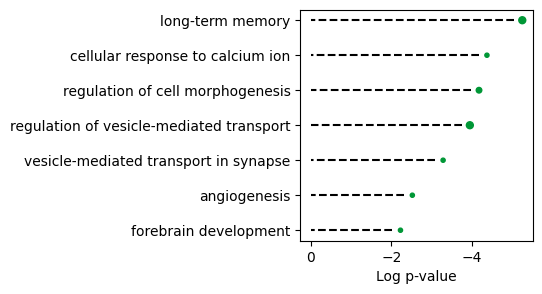

In [ ]:
plt.figure(figsize=(3,4))
plt.scatter(x=df['logP'], y=df['GO'], s=df['nb_gene']**2, cmap='viridis')

for idx, go in enumerate(df['GO'].unique()):
    plt.hlines(y=df['GO'][idx], xmin=df['logP'][idx]+0.2, xmax=0, color = 'black', linestyle = 'dashed') 

plt.xlabel('Log p-value')
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

plt.savefig(f'Gallery/{today}/GO_{filename_}.svg', transparent= True, dpi=300)